In [18]:
# Instalação Limpa (evita erros de versão)
!pip uninstall pysus -y
!pip install pysus sidrapy pandas fastparquet pyarrow --upgrade --no-cache-dir

import pandas as pd
import sidrapy
import os
import gc # gerenciador de memória (baixar dados de todos os municípios do Brasil)
from pysus import SIH, SIM, SINASC
import numpy as np

Found existing installation: pysus 1.0.0
Uninstalling pysus-1.0.0:
  Successfully uninstalled pysus-1.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 32.4 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.8 MB/s eta 0:00:00a 0:00:01


In [19]:
def baixar_ibge():
     
    # População (Censo 2022) - Tabela 4714
    print("> Baixando População 2022...")
    pop = sidrapy.get_table(table_code="4714", territorial_level="6", ibge_territorial_code="all", variable="93", period="2022")
    pop = pop.iloc[1:][['D1C', 'D1N', 'V']].rename(columns={'D1C':'cod', 'D1N':'mun', 'V':'populacao'})
    
    # PIB (Último disponível) - Tabela 5938
    print("> Baixando PIB...")
    pib = sidrapy.get_table(table_code="5938", territorial_level="6", ibge_territorial_code="all", variable="37", period="last")
    pib = pib.iloc[1:][['D1C', 'V']].rename(columns={'D1C':'cod', 'V':'pib_total'})
    
    # Saneamento (Censo 2010 - Proxy mais estável via API enquanto 2022 não estabiliza tabela)
    # Tabela 1442: Domicílios com esgotamento sanitário adequado
    # Se der erro, o código segue sem ele.
    try:
        print("> Tentando baixar Saneamento...")
        san = sidrapy.get_table(table_code="1442", territorial_level="6", ibge_territorial_code="all", variable="1000096", period="2010")
        san = san.iloc[1:][['D1C', 'V']].rename(columns={'D1C':'cod', 'V':'domicilios_esgoto'})
    except:
        print("  [!] Saneamento via API falhou. Seguiremos sem essa variável.")
        san = pd.DataFrame(columns=['cod', 'domicilios_esgoto'])

    # Merge e Tratamento
    df = pd.merge(pop, pib, on='cod')
    if not san.empty:
        df = pd.merge(df, san, on='cod', how='left')
        
    df['populacao'] = pd.to_numeric(df['populacao'], errors='coerce')
    df['pib_total'] = pd.to_numeric(df['pib_total'].astype(str).str.replace(',', '.'), errors='coerce') * 1000
    df['pib_per_capita'] = df['pib_total'] / df['populacao']
    
    # Chave de 6 dígitos para o SUS
    df['cod_ibge_6'] = df['cod'].str[:6]
    
    df.to_csv('dimensao_estrutura_ibge.csv', index=False)
    print(f"IBGE Pronto: {len(df)} cidades.")

baixar_ibge()

> Baixando População 2022...
> Baixando PIB...
> Tentando baixar Saneamento...
IBGE Pronto: 5570 cidades.


In [20]:
from pysus import SIH
import pandas as pd
import os
import gc
import numpy as np

def baixar_sih():
    print("BAIXANDO MORBIDADE (SIH - Custos e Internações)")
    
    if not os.path.exists('temp_sih'): os.makedirs('temp_sih')
    
    sih = SIH()
    sih.load()
    
    ufs = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 
           'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 
           'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']
    
    cids_icsap = tuple(['A00', 'A01', 'A09', 'E10', 'E11', 'E14', 'I10', 'J45', 'J15', 'N10'])

    for uf in ufs:
        arquivo = f'temp_sih/sih_{uf}.csv'
        # Vamos forçar baixar de novo para corrigir o erro, então tirei o "continue" se já existe
        
        try:
            print(f"  > {uf}...", end=" ")
            arquivos = sih.get_files("RD", uf=uf, year=2024, month=[1,2,3])
            
            if not arquivos:
                print("(Sem arquivos)")
                continue
            
            # Baixa e Concatena
            parquets = sih.download(arquivos)
            df = pd.concat([p.to_dataframe() for p in parquets])
            df.columns = [c.upper() for c in df.columns]
            
            # --- O PULO DO GATO (CORREÇÃO DE VALOR) ---
            if 'VAL_TOT' in df.columns:
                # 1. Garante que é texto (str)
                # 2. Troca vírgula por ponto
                # 3. Converte para número
                df['VAL_TOT'] = df['VAL_TOT'].astype(str).str.replace(',', '.')
                df['VAL_TOT'] = pd.to_numeric(df['VAL_TOT'], errors='coerce').fillna(0)
            else:
                df['VAL_TOT'] = 0.0
            
            # Resto do processamento normal...
            df['flag_icsap'] = df['DIAG_PRINC'].fillna('').str.startswith(cids_icsap).astype(int)
            df['flag_obito'] = df['MORTE'].fillna(0).astype(int)
            
            if 'MUNIC_RES' in df.columns:
                df['MUNIC_RES'] = df['MUNIC_RES'].astype(str).str.replace(r'[^\w]', '', regex=True).str[:6]
                
                agrupado = df.groupby('MUNIC_RES').agg(
                    internacoes=('MUNIC_RES', 'count'),
                    icsap=('flag_icsap', 'sum'),
                    obitos=('flag_obito', 'sum'),
                    custo_total=('VAL_TOT', 'sum')
                ).reset_index()
                
                agrupado.to_csv(arquivo, index=False)
                print(f"OK (Custo Total UF: R$ {agrupado['custo_total'].sum():,.2f})")
            
            del df, agrupado
            gc.collect()
            
        except Exception as e:
            print(f"Erro {uf}: {e}")

    # Consolidar
    dfs = [pd.read_csv(f'temp_sih/{f}', dtype={'MUNIC_RES':str}) for f in os.listdir('temp_sih') if f.endswith('.csv')]
    
    if dfs:
        final = pd.concat(dfs).groupby('MUNIC_RES').sum().reset_index()
        final.rename(columns={'MUNIC_RES':'cod_ibge_6'}, inplace=True)
        final.to_csv('dimensao_morbidade_sus.csv', index=False)
        print(f"SIH Pronto! Custo Total Brasil na amostra: R$ {final['custo_total'].sum():,.2f}")
    else:
        print("Erro.")

baixar_sih()

BAIXANDO MORBIDADE (SIH - Custos e Internações)
  > AC... 

RDAC2403.parquet: 100%|██████████| 15.9k/15.9k [00:00<00:00, 35.6kB/s]


OK (Custo Total UF: R$ 13,219,786.31)
  > AL... 

RDAL2403.parquet: 100%|██████████| 51.4k/51.4k [00:01<00:00, 30.3kB/s]


OK (Custo Total UF: R$ 59,975,417.12)
  > AP... 

...

OK (Custo Total UF: R$ 1,217,408,478.33)
  > SE... 

RDSE2403.parquet: 100%|██████████| 35.1k/35.1k [00:01<00:00, 32.3kB/s]


OK (Custo Total UF: R$ 45,528,288.50)
  > TO... 

RDTO2403.parquet: 100%|██████████| 29.5k/29.5k [00:00<00:00, 34.3kB/s]


OK (Custo Total UF: R$ 27,949,942.18)
SIH Pronto! Custo Total Brasil na amostra: R$ 5,503,026,101.21


In [21]:
def baixar_sim():
    print("BAIXANDO MORTALIDADE (SIM - Óbitos)")
    
    # Cria pasta temporária se não existir
    if not os.path.exists('temp_sim'): 
        os.makedirs('temp_sim')
    
    # Carrega metadados da biblioteca
    sim = SIM().load()
    
    # Vamos verificar qual chave está disponível para evitar o KeyError (erro de versões)
    grupo_alvo = 'CID10'
    if 'CID10' not in sim.groups and 'DO' in sim.groups:
        grupo_alvo = 'DO'
    
    print(f"Usando grupo de dados: {grupo_alvo}")

    ufs = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 
           'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 
           'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']
    
    for uf in ufs:
        arquivo = f'temp_sim/sim_{uf}.csv'
        
        # Pula se já baixou
        if os.path.exists(arquivo): 
            print(f"  > {uf} já existe.", end=" ")
            continue
        
        try:
            print(f"  > {uf}...", end=" ")
            
            arquivos = sim.get_files(grupo_alvo, uf=uf, year=2022) 
            
            if not arquivos: 
                print("Sem arquivos.")
                continue
            
            # Baixa e converte
            df = sim.download(arquivos).to_dataframe()
            df.columns = [c.upper() for c in df.columns]
            
            # CÁLCULO DOS INDICADORES
            
            # Infantil (Idade < 1 ano)
            # Lógica SUS: Dígito da unidade de tempo (0=min, 1=hora, 2=dia, 3=mês, 4=ano, 5=>100 anos)
            # Se o valor for menor que 400, significa que a unidade é 0, 1, 2 ou 3 (ou seja, menos de 1 ano).
            df['IDADE'] = pd.to_numeric(df['IDADE'], errors='coerce').fillna(999)
            df['infantil'] = df['IDADE'].apply(lambda x: 1 if x < 400 else 0)
            
            # Violência (Causas Externas - Cap XX: V, W, X, Y)
            df['violencia'] = df['CAUSABAS'].fillna('').str.startswith(('V', 'W', 'X', 'Y')).astype(int)
            
            # Agrupa
            if 'CODMUNRES' in df.columns:
                df['CODMUNRES'] = df['CODMUNRES'].astype(str).str[:6]
                
                agrupado = df.groupby('CODMUNRES').agg(
                    obitos_totais=('CODMUNRES', 'count'),
                    obitos_infantil=('infantil', 'sum'),
                    obitos_violencia=('violencia', 'sum')
                ).reset_index()
                
                agrupado.to_csv(arquivo, index=False)
                print("OK")
            
            # Limpeza de memória
            del df, agrupado
            gc.collect()
            
        except Exception as e:
            print(f"Erro {uf}: {e}")

    # Consolidar Brasil
    print("\nConsolidando SIM...")
    
    # Filtra apenas arquivos .csv para evitar erros de leitura
    lista_arquivos = [f for f in os.listdir('temp_sim') if f.endswith('.csv')]
    
    if lista_arquivos:
        dfs = [pd.read_csv(f'temp_sim/{f}', dtype={'CODMUNRES':str}) for f in lista_arquivos]
        final = pd.concat(dfs).groupby('CODMUNRES').sum().reset_index()
        final.rename(columns={'CODMUNRES':'cod_ibge_6'}, inplace=True)
        final.to_csv('dimensao_mortalidade_sus.csv', index=False)
        print(f"SIM Pronto: {len(final)} cidades processadas.")
    else:
        print("Nenhum arquivo processado.")

baixar_sim()

BAIXANDO MORTALIDADE (SIM - Óbitos)
Usando grupo de dados: CID10
  > AC já existe.   > AL já existe.   > AP já existe.   > AM já existe.   > BA já existe.   > CE já existe.   > DF já existe.   > ES já existe.   > GO já existe.   > MA já existe.   > MT já existe.   > MS já existe.   > MG já existe.   > PA já existe.   > PB já existe.   > PR já existe.   > PE já existe.   > PI já existe.   > RJ já existe.   > RN já existe.   > RS já existe.   > RO já existe.   > RR já existe.   > SC já existe.   > SP já existe.   > SE já existe.   > TO já existe. 
Consolidando SIM...
SIM Pronto: 5594 cidades processadas.


In [22]:
def baixar_sinasc():
    print("BAIXANDO PREVENÇÃO (SINASC - Nascimentos)")
    if not os.path.exists('temp_sinasc'): os.makedirs('temp_sinasc')
    
    sinasc = SINASC().load()
    ufs = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']
    
    for uf in ufs:
        arquivo = f'temp_sinasc/sinasc_{uf}.csv'
        if os.path.exists(arquivo): continue
        
        try:
            print(f"  > {uf}...", end=" ")
            arquivos = sinasc.get_files("DN", uf=uf, year=2022)
            if not arquivos: continue
            
            df = sinasc.download(arquivos).to_dataframe()
            df.columns = [c.upper() for c in df.columns]
            
            # CÁLCULO DOS INDICADORES
            # Pré-natal Bom (7+ consultas = Código 4)
            df['prenatal_bom'] = pd.to_numeric(df['CONSULTAS'], errors='coerce').apply(lambda x: 1 if x == 4 else 0)
            
            # Mãe Adolescente (< 19 anos)
            df['mae_adolescente'] = pd.to_numeric(df['IDADEMAE'], errors='coerce').apply(lambda x: 1 if x < 19 else 0)
            
            if 'CODMUNRES' in df.columns:
                df['CODMUNRES'] = df['CODMUNRES'].astype(str).str[:6]
                agrupado = df.groupby('CODMUNRES').agg(
                    nascimentos=('CODMUNRES', 'count'),
                    prenatal_ok=('prenatal_bom', 'sum'),
                    maes_jovens=('mae_adolescente', 'sum')
                ).reset_index()
                
                agrupado.to_csv(arquivo, index=False)
            
            del df, agrupado
            gc.collect()
            
        except Exception as e:
            print(f"Erro {uf}: {e}")

    # Consolidar
    print("\nConsolidando SINASC...")
    dfs = [pd.read_csv(f'temp_sinasc/{f}', dtype={'CODMUNRES':str}) for f in os.listdir('temp_sinasc')]
    if dfs:
        final = pd.concat(dfs).groupby('CODMUNRES').sum().reset_index()
        final.rename(columns={'CODMUNRES':'cod_ibge_6'}, inplace=True)
        final.to_csv('dimensao_prevencao_sus.csv', index=False)
        print("SINASC Pronto.")

baixar_sinasc()

BAIXANDO PREVENÇÃO (SINASC - Nascimentos)

Consolidando SINASC...
SINASC Pronto.


In [23]:
import numpy as np

def gerar_tabela_mestra():
    print("GERANDO TABELA MESTRA")
    
    try:
        # Carrega tudo
        ibge = pd.read_csv('dimensao_estrutura_ibge.csv', dtype={'cod_ibge_6': str})
        sih = pd.read_csv('dimensao_morbidade_sus.csv', dtype={'cod_ibge_6': str})
        sim = pd.read_csv('dimensao_mortalidade_sus.csv', dtype={'cod_ibge_6': str})
        sinasc = pd.read_csv('dimensao_prevencao_sus.csv', dtype={'cod_ibge_6': str})
        
    except FileNotFoundError:
        print("Erro.")
        return

    # Merges em Cascata
    df = pd.merge(ibge, sih, on='cod_ibge_6', how='left')
    df = pd.merge(df, sim, on='cod_ibge_6', how='left')
    df = pd.merge(df, sinasc, on='cod_ibge_6', how='left')
    
    # Tratamento de Nulos
    cols_numericas = [
        'populacao', 'internacoes', 'icsap', 'custo_total', 
        'obitos_infantil', 'nascimentos', 'obitos_violencia', 
        'obitos_totais', 'prenatal_ok'
    ]
    
    for col in cols_numericas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    
    # Indicadores Anteriores
    df['taxa_internacao'] = np.where(df['populacao'] > 0, (df['internacoes'] / df['populacao']) * 1000, 0)
    df['pct_icsap'] = np.where(df['internacoes'] > 0, (df['icsap'] / df['internacoes']) * 100, 0)
    df['custo_medio'] = np.where(df['internacoes'] > 0, df['custo_total'] / df['internacoes'], 0)
    df['taxa_mortalidade_infantil'] = np.where(df['nascimentos'] > 0, (df['obitos_infantil'] / df['nascimentos']) * 1000, 0)
    df['pct_violencia'] = np.where(df['obitos_totais'] > 0, (df['obitos_violencia'] / df['obitos_totais']) * 100, 0)
    df['pct_prenatal'] = np.where(df['nascimentos'] > 0, (df['prenatal_ok'] / df['nascimentos']) * 100, 0)

    
    # Salvar
    df.to_csv('DATASET_MESTRE_FINAL.csv', index=False)
    print("Dataset Mestre Pronto.")

gerar_tabela_mestra()

GERANDO TABELA MESTRA
Dataset Mestre Pronto.


DATASET MESTRE


Arquivo carregado com sucesso!
Dimensões: 5570 cidades x 22 colunas

 VISUALIZAÇÃO DAS PRIMEIRAS LINHAS
                          mun  pib_per_capita  taxa_internacao  pct_icsap  \
0  Alta Floresta D'Oeste - RO    48680.701591        43.453987   6.316916   
1              Ariquemes - RO    45271.911435        17.473382   4.018913   
2                 Cabixi - RO    56219.772005        14.950477   3.750000   
3                 Cacoal - RO    44292.794089        25.941740   5.146406   
4             Cerejeiras - RO    63334.738829        24.103210   8.616188   
5      Colorado do Oeste - RO    37087.339590        17.684990   5.054152   
6             Corumbiara - RO    67770.448198        11.038702   1.204819   
7          Costa Marques - RO    32782.371110        10.374594   1.526718   
8        Espigão D'Oeste - RO    34812.436255        22.710274   6.586826   
9          Guajará-Mirim - RO    29071.368726        30.492294  13.905079   

   taxa_mortalidade_infantil  pct_prenatal  
0  

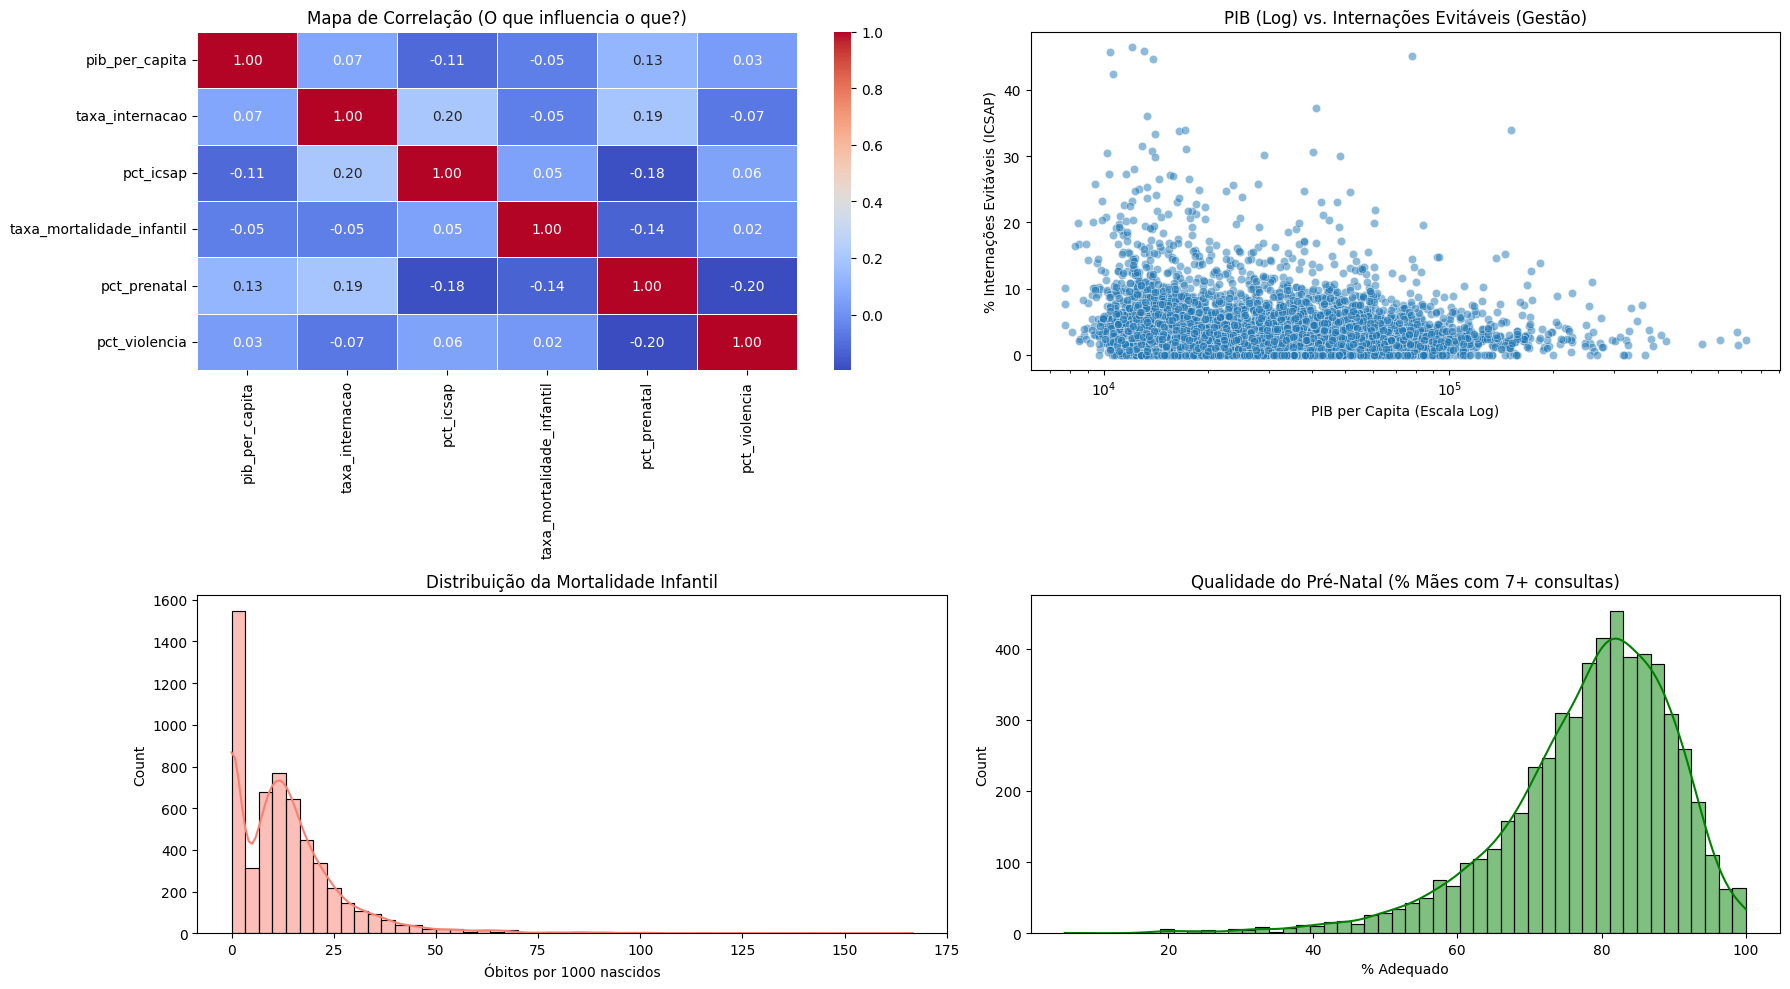

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def auditar_dataset_final():
    print("DATASET MESTRE")
    
    # Carregar
    try:
        df = pd.read_csv('DATASET_MESTRE_FINAL.csv', dtype={'cod_ibge_6': str})
        print(f"Arquivo carregado com sucesso!")
        print(f"Dimensões: {df.shape[0]} cidades x {df.shape[1]} colunas")
    except FileNotFoundError:
        print("Erro: arquivo 'DATASET_MESTRE_FINAL.csv' não foi encontrado.")
        return

    # Espiada nos Dados (Head)
    print("\n VISUALIZAÇÃO DAS PRIMEIRAS LINHAS")
    # Mostra colunas principais para não poluir
    cols_view = ['mun', 'pib_per_capita', 'taxa_internacao', 'pct_icsap', 'taxa_mortalidade_infantil', 'pct_prenatal']
    print(df[cols_view].head(10))

    # Checagem de Nulos (Zeros disfarçados)
    print("\n CHECAGEM DE DADOS FALTANTES")
    # Conta quantos zeros existem nas colunas chave (pode indicar falta de dado original)
    zeros_pib = (df['pib_per_capita'] == 0).sum()
    zeros_icsap = (df['pct_icsap'] == 0).sum()
    zeros_mortalidade = (df['taxa_mortalidade_infantil'] == 0).sum()
    
    print(f"Cidades com PIB zerado: {zeros_pib}")
    print(f"Cidades com ICSAP zerado (Suspeito): {zeros_icsap}")
    print(f"Cidades com Mort. Infantil zerada (Comum em cidades pqnas): {zeros_mortalidade}")

    # Estatísticas Descritivas
    print("\n ESTATÍSTICAS GERAIS (Média, Mín, Máx)")
    print(df[['pib_per_capita', 'pct_icsap', 'taxa_mortalidade_infantil', 'pct_prenatal']].describe().round(2))

    # GRÁFICOS DE DIAGNÓSTICO
    print("\n GERANDO GRÁFICOS...")
    
    # Configura o tamanho da figura
    plt.figure(figsize=(18, 10))

    # Gráfico A: Correlação (Mapa de Calor)
    # Isso mostra se Riqueza (PIB) tem a ver com Saúde (Mortalidade/ICSAP)
    plt.subplot(2, 2, 1)
    cols_corr = ['pib_per_capita', 'taxa_internacao', 'pct_icsap', 'taxa_mortalidade_infantil', 'pct_prenatal', 'pct_violencia']
    corr = df[cols_corr].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Mapa de Correlação (O que influencia o que?)')

    # Gráfico B: Riqueza x Ineficiência (Scatter Plot)
    plt.subplot(2, 2, 2)
    sns.scatterplot(data=df, x='pib_per_capita', y='pct_icsap', alpha=0.5)
    plt.xscale('log') # Escala logarítmica porque o PIB varia muito
    plt.title('PIB (Log) vs. Internações Evitáveis (Gestão)')
    plt.xlabel('PIB per Capita (Escala Log)')
    plt.ylabel('% Internações Evitáveis (ICSAP)')

    # Gráfico C: Distribuição da Mortalidade Infantil
    plt.subplot(2, 2, 3)
    sns.histplot(df['taxa_mortalidade_infantil'], bins=50, kde=True, color='salmon')
    plt.title('Distribuição da Mortalidade Infantil')
    plt.xlabel('Óbitos por 1000 nascidos')

    # Gráfico D: Distribuição do Pré-Natal
    plt.subplot(2, 2, 4)
    sns.histplot(df['pct_prenatal'], bins=50, kde=True, color='green')
    plt.title('Qualidade do Pré-Natal (% Mães com 7+ consultas)')
    plt.xlabel('% Adequado')

    plt.tight_layout()
    plt.show()

# Executar
auditar_dataset_final()